# CEDAR Deep Dive

## What is CEDAR?

**CEDAR** (Causal Edge Discovery for Autoregressive processes) is a constraint-based algorithm for causal discovery in autoregressive time series. Its key idea is to avoid the exponential conditioning-set explosion of PC/PCMCI by using *minimum-lag selection* to build small, targeted conditioning sets.

### How it works (3-phase pipeline)

```
Phase 0  Lag selection
         Compute distance correlation (dcor) between all variable pairs at each lag.
         Run a t-test (or permutation) to find which lags are statistically significant.
         Select the most important lag per pair as the "minimum lag" w_{ij}.

Phase 1  Condition 1 — dependence test
         For each candidate cause Xi and target Xj at lag w_{ij}:
         Test Xi(t) ⊥ Xj(t+w) | {Xj(t+w-1), other candidates at their lags}
         Accept the edge candidate if p < α_cond1.

Phase 2  Condition 2 — independence test (AR check)
         Test Xi(t-1) ⊥ Xj(t+w) | {same conditioning set, Xi(t)}
         Accept the final edge if p ≥ α_cond2.
         (AR/Markov screen: Xi(t) must render Xi(t-1) independent of Xj.

Phase 3  MCI pruning (optional)
         For each accepted edge Xi(t-τ) → Xj(t), run one more CI test
         conditioning on parents of BOTH Xi and Xj. Removes false positive links.
```

### Key properties

| Property | Details |
|-----------|---------|
| **Complexity** | O(d²) CI tests (vs O(d^k) for PC/FCI) |
| **Lag selection** | Unbiased U-centered dcor — detects nonlinear lags, not just linear |
| **CI test** | Any `causalts.ci_tests` instance (ParCorr, KCI, SplitKCI, DFCIT, …) |
| **target_var** | Discover causes of a single variable: O(d) tests — unique to CEDAR |
| **Multi-lag** | Can report all accepted lags per pair, not just the top one |
| **MCI pruning** | Stable (order-independent) removal of indirect edges |

---

## Notebook contents
1. Head-to-head vs CDNOTS and old CEDAR on all standard benchmarks
2. Ablation: effect of key options (`multi_lag_keep`, `filter_children`, `prune`, …)
3. Lag selection diagnostics — where and why lags are wrong
4. Scaling to larger graphs (d=20 Erdős–Rényi)
5. **Target-variable mode** — discover causes of a single variable (unique to CEDAR)
6. Nonlinear datasets with kernel CI tests
7. Plotting
8. Background knowledge
9. Effect estimation (DoWhy)
10. Missing values
11. **Nonstationary time series (C node)** — include_C=True absorbs shared trends; confounded_trends demo

In [1]:
import warnings
warnings.filterwarnings('ignore')
import time
import numpy as np
import pandas as pd
from causalts.ci_tests import ParCorrGPU, SplitKCIGPU, KCIGPU
from causalts.cedar import SYPI, Cedar, run_cedar, CedarResult
from causalts import run_cdnots
from causalts.synthetic_data import synthetic_datasets as sd
from causalts.utils.helpers import precision_recall_3d, shd_3d

DEVICE = 'cpu' #'cuda if torch.cuda.is_available() else 'cpu'

def eval_graph(est, gt_clean):
    """Evaluate estimated graph against ground truth, excluding self-loops from both."""
    est = est.copy()
    for lag in range(est.shape[2]):
        np.fill_diagonal(est[:, :, lag], 0)
    if est.shape[2] < gt_clean.shape[2]:
        est = np.concatenate([est, np.zeros((*est.shape[:2], gt_clean.shape[2] - est.shape[2]))], axis=2)
    elif est.shape[2] > gt_clean.shape[2]:
        est = est[:, :, :gt_clean.shape[2]]
    prec, rec = precision_recall_3d(gt_clean, est)
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    shd = shd_3d(gt_clean, est)
    edges = int(est.astype(bool).sum())
    return prec, rec, f1, shd, edges

def load_dataset(name, **kwargs):
    data = getattr(sd, name)(**kwargs)
    gt = data['ground_truth'].copy()
    for lag in range(gt.shape[2]):
        np.fill_diagonal(gt[:, :, lag], 0)
    data['gt_clean'] = gt
    return data

## 1. Head-to-Head: All Methods on Standard Benchmarks

### `multi_lag_keep` — precision vs recall tradeoff

CEDAR tests each candidate's lags in descending importance order (highest dcor score first). `multi_lag_keep` controls what happens after the first lag passes both conditions:

| Value | Behaviour | Effect |
|-------|-----------|--------|
| `'first'` (default) | Stop at the first accepted lag per candidate pair | Higher precision, fewer CI tests, faster |
| `'all'` | Continue testing all remaining significant lags; report every accepted lag | Higher recall, captures genuine multi-lag effects, more tests |

**Rule of thumb:** use `'first'` for standard VAR-type data where each variable pair has one dominant lag. Use `'all'` when the system has long-memory or oscillatory dynamics and recall matters more than precision. The ablation in Section 2 quantifies this tradeoff on ex3.

In [2]:
datasets = {name: load_dataset(name) for name in ['ex1_nl', 'ex2', 'ex3', 'henon_chain']}

# Store discovered graphs keyed by (dataset, method) for the plot below
all_graphs = {name: {} for name in datasets}

rows = []
for name, data in datasets.items():
    df, gt, ml = data['df'], data['gt_clean'], data['max_lag']
    d = df.shape[1]
    ci = ParCorrGPU(np.zeros((2,2)), device=DEVICE)

    for method, run_fn in [
        ('CDNOTS', lambda: run_cdnots(df, ci, num_lags=ml, alpha=0.05)),
        ('Old CEDAR', None),
        ('keep=first', lambda: run_cedar(df, ci, max_lag=ml, multi_lag_keep='first')),
        ('keep=all', lambda: run_cedar(df, ci, max_lag=ml, multi_lag_keep='all')),
    ]:
        t0 = time.time()
        if method == 'Old CEDAR':
            so = SYPI(data=df, ci_test=ci, max_lag=ml, lag_sel_algo='dcor',
                      p_cond1=0.05, p_cond2=0.05, make_log=False,
                      filter_potential_children=True, cache_dir='/tmp/nb_cache')
            so.run_ts_causality()
            est = so.graph_pruned if so.graph_pruned is not None else so.graph
        elif method == 'CDNOTS':
            res = run_fn()
            est = res.cg_tig[:d, :d, :]
        else:
            res = run_fn()
            est = res.cg_tig
        elapsed = time.time() - t0
        p, r, f, s, e = eval_graph(est, gt)
        rows.append({'dataset': name, 'method': method, 'time': f'{elapsed:.2f}s',
                     'edges': e, 'prec': round(p,3), 'rec': round(r,3),
                     'f1': round(f,3), 'shd': s})
        all_graphs[name][method] = est

results_df = pd.DataFrame(rows)


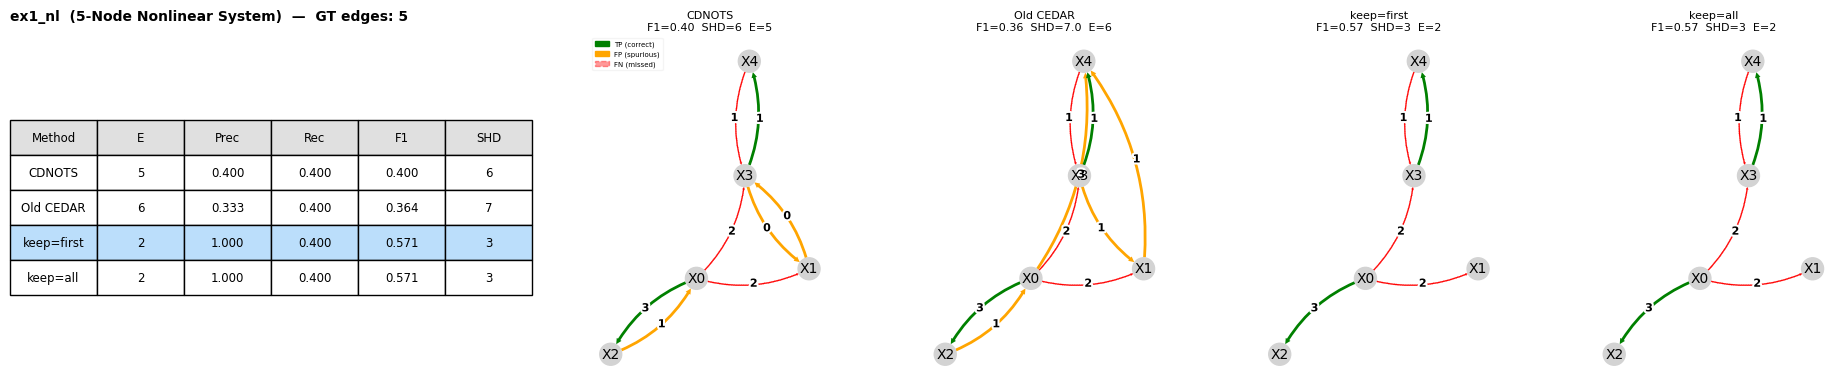

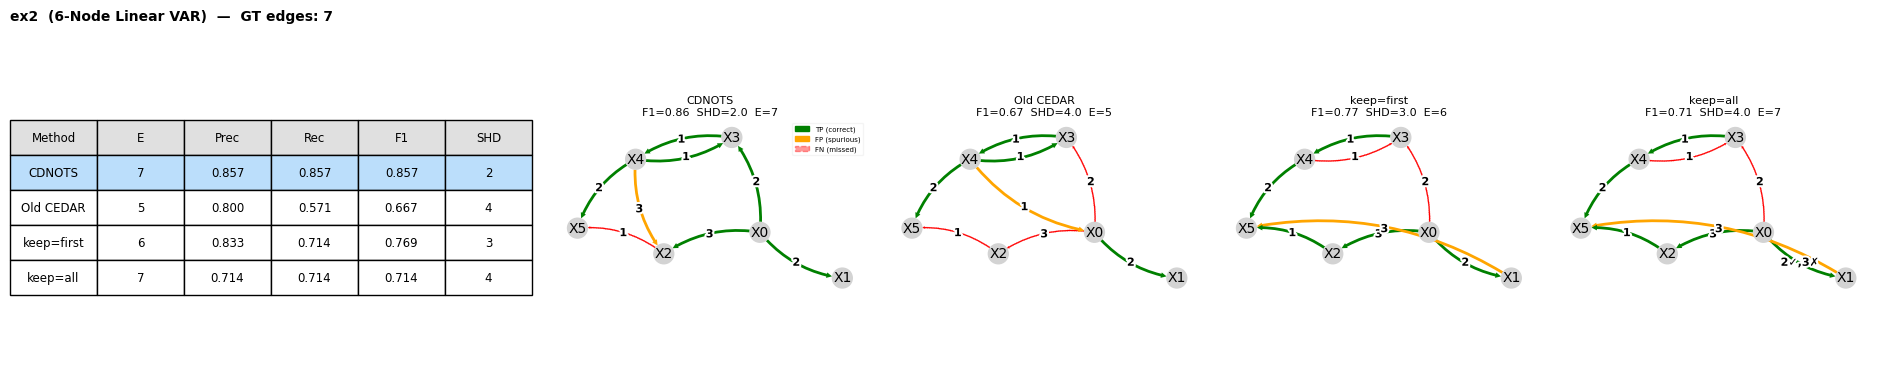

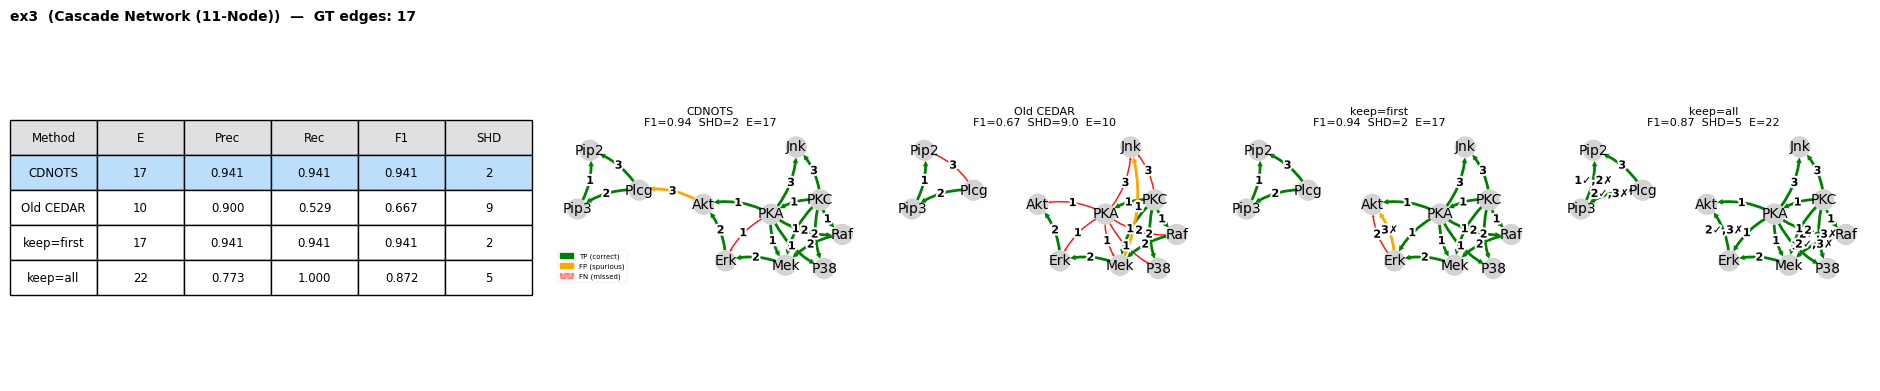

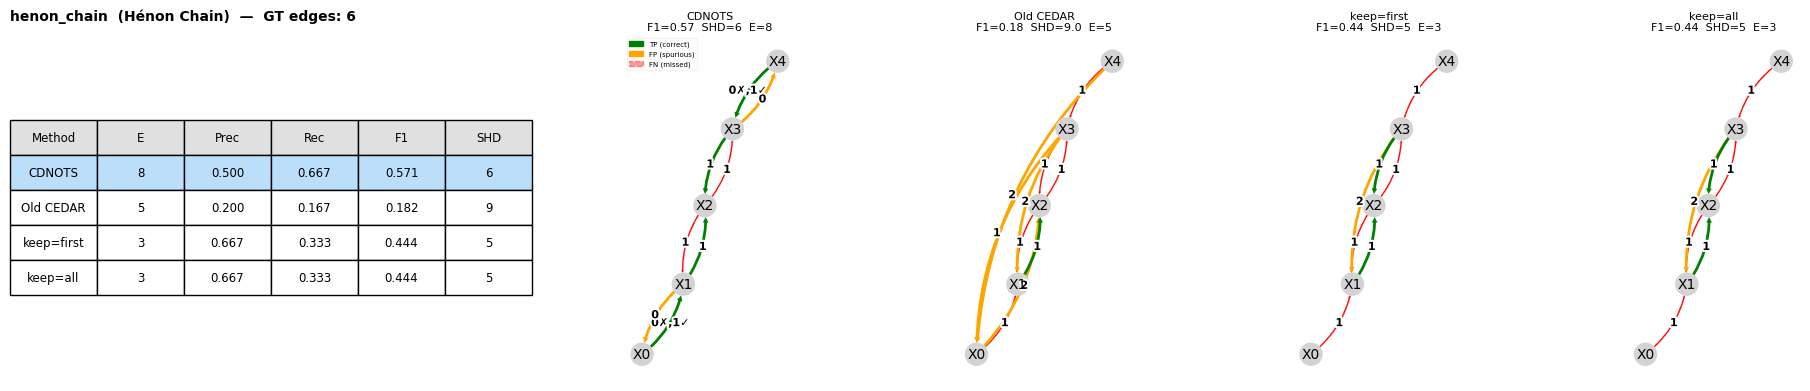

In [3]:
import causalts.plotting as tp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

methods_list = ['CDNOTS', 'Old CEDAR', 'keep=first', 'keep=all']

def _align(est, gt):
    """Pad or trim the lag axis so shapes match."""
    if est.shape[2] < gt.shape[2]:
        pad = np.zeros((*est.shape[:2], gt.shape[2] - est.shape[2]))
        return np.concatenate([est, pad], axis=2)
    return est[:, :, :gt.shape[2]]

for ds_name, ds_data in datasets.items():
    gt       = ds_data['gt_clean']
    var_names = list(ds_data['df'].columns)
    gt_edges  = int(gt.astype(bool).sum())
    ds_rows   = results_df[results_df['dataset'] == ds_name]

    fig = plt.figure(figsize=(24, 4.5))
    gs  = gridspec.GridSpec(1, 5, figure=fig,
                            width_ratios=[2.0, 1.2, 1.2, 1.2, 1.2],
                            wspace=0.06)

    # ── Col 0: metrics table ──────────────────────────────────────────────
    ax_t = fig.add_subplot(gs[0, 0])
    ax_t.axis('off')

    col_labels = ['Method', 'E', 'Prec', 'Rec', 'F1', 'SHD']
    table_rows = []
    for m in methods_list:
        r = ds_rows[ds_rows['method'] == m].iloc[0]
        table_rows.append([m, int(r['edges']),
                           f"{r['prec']:.3f}", f"{r['rec']:.3f}",
                           f"{r['f1']:.3f}", int(r['shd'])])

    tbl = ax_t.table(cellText=table_rows, colLabels=col_labels,
                     loc='center', cellLoc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8.5)
    tbl.scale(1, 2.1)

    # Highlight the row with the best F1 in light blue
    f1_vals = [float(r[4]) for r in table_rows]
    best    = int(np.argmax(f1_vals))
    for col in range(len(col_labels)):
        tbl[(best + 1, col)].set_facecolor('#BBDEFB')
        tbl[(0, col)].set_facecolor('#E0E0E0')

    ax_t.set_title(
        f"{ds_name}  ({ds_data['name']})  —  GT edges: {gt_edges}",
        fontsize=10, loc='left', pad=10, fontweight='bold',
    )

    # ── Cols 1-4: compare graphs (TP/FP/FN coloring) ─────────────────────
    pos = None
    for col_idx, method in enumerate(methods_list):
        ax    = fig.add_subplot(gs[0, col_idx + 1])
        graph = _align(all_graphs[ds_name][method], gt)
        p, r, f, s, e = eval_graph(graph, gt)

        kwargs = dict(
            graph_true=gt, graph_discovered=graph,
            var_names=var_names,
            arrow_linewidth=2, link_label_fontsize=8,
            node_size=0.15, node_label_size=10,
            show_legend=(col_idx == 0),
            legend_loc=None,
            legend_fontsize=5,
            legend_framealpha=0.2,
            legend_markerscale=.5,
            fig_ax=(fig, ax),
        )
        if pos is not None:
            kwargs['node_pos'] = pos
        else:
            kwargs['return_pos'] = True

        out = tp.compare_graphs(**kwargs)
        if pos is None:
            _, _, pos = out

        ax.set_title(f"{method}\nF1={f:.2f}  SHD={s}  E={e}",
                     fontsize=8, pad=3)

    plt.tight_layout()
    plt.show()


## 2. Ablation: Effect of Key Options

Test the impact of each option on ex3 (the most informative benchmark — 11 vars, 17 true edges).

### Option reference

| Option | What it controls | Default |
|--------|-----------------|---------|
| `multi_lag_keep` | Whether to stop at the first accepted lag (`'first'`) or report all (`'all'`) | `'first'` |
| `multi_lag` | Whether to test multiple significant lags at all, or only the top lag | `True` |
| `filter_children` | Skip candidates whose dcor asymmetry strongly suggests they are *effects*, not causes | `True` |
| `prune` | Run MCI-style pruning pass after discovery to remove indirect links | `True` |
| `lag_alpha` | P-value threshold for lag significance — controls how many lags enter as candidates | `0.05` |
| `alpha_cond1` | Threshold for the dependence test (Phase 1); lower → more selective | `0.05` |

**What to look for:**

- **`prune=False`** — removing the MCI pass inflates edge count and hurts precision most; this is the biggest quality lever.
- **`filter_children=False`** — disabling direction filtering adds more candidate tests but rarely changes the result on well-structured data; more impact on dense graphs.
- **`multi_lag=False`** (single-lag only) — limits each pair to the single top lag; slightly lower recall when true effects span multiple lags.
- **`keep=all`** — increases recall at the cost of extra false positives from weaker lags.
- **`lag_alpha`/`alpha_cond1`** — loosening these thresholds expands the candidate set and raises recall, but also FP rate.

In [23]:
data = load_dataset('ex3')
df, gt, ml = data['df'], data['gt_clean'], data['max_lag']
ci = ParCorrGPU(np.zeros((2,2)), device=DEVICE)

configs = {
    'defaults (multi_lag, keep=first)': dict(),
    'keep=all': dict(multi_lag_keep='all'),
    'no child filter': dict(filter_children=False),
    'no MCI pruning': dict(prune=False),
    'no filter + no prune': dict(filter_children=False, prune=False),
    'single-lag only': dict(multi_lag=False),
    'lag_alpha=0.10': dict(lag_alpha=0.10),
    'alpha_cond1=0.10': dict(alpha_cond1=0.10),
    'keep=all + no filter': dict(multi_lag_keep='all', filter_children=False),
}

print(data['name'])
print(f"{'Config':35s} | {'E':>3s} | {'Prec':>5s} {'Rec':>5s} {'F1':>5s} {'SHD':>4s} | {'Tests':>5s}")
print('-' * 75)

for config_name, kwargs in configs.items():
    result = run_cedar(df, ci, max_lag=ml, **kwargs)
    p, r, f, s, e = eval_graph(result.cg_tig, gt)
    print(f'{config_name:35s} | {e:3d} | {p:.3f} {r:.3f} {f:.3f} {s:>4} | {result.n_tests:>5d}')

Cascade Network (11-Node)
Config                              |   E |  Prec   Rec    F1  SHD | Tests
---------------------------------------------------------------------------
defaults (multi_lag, keep=first)    |  17 | 1.000 1.000 1.000    0 |    76
keep=all                            |  22 | 0.773 1.000 0.872    5 |   113
no child filter                     |  17 | 1.000 1.000 1.000    0 |    76
no MCI pruning                      |  24 | 0.708 1.000 0.829    7 |    52
no filter + no prune                |  24 | 0.708 1.000 0.829    7 |    52
single-lag only                     |  16 | 1.000 0.941 0.970    1 |    73
lag_alpha=0.10                      |  17 | 1.000 1.000 1.000    0 |    76
alpha_cond1=0.10                    |  18 | 0.944 1.000 0.971    1 |    78
keep=all + no filter                |  22 | 0.773 1.000 0.872    5 |   113


## 3. Lag Selection Diagnostics

For each ground-truth edge, show what lag was selected and why.

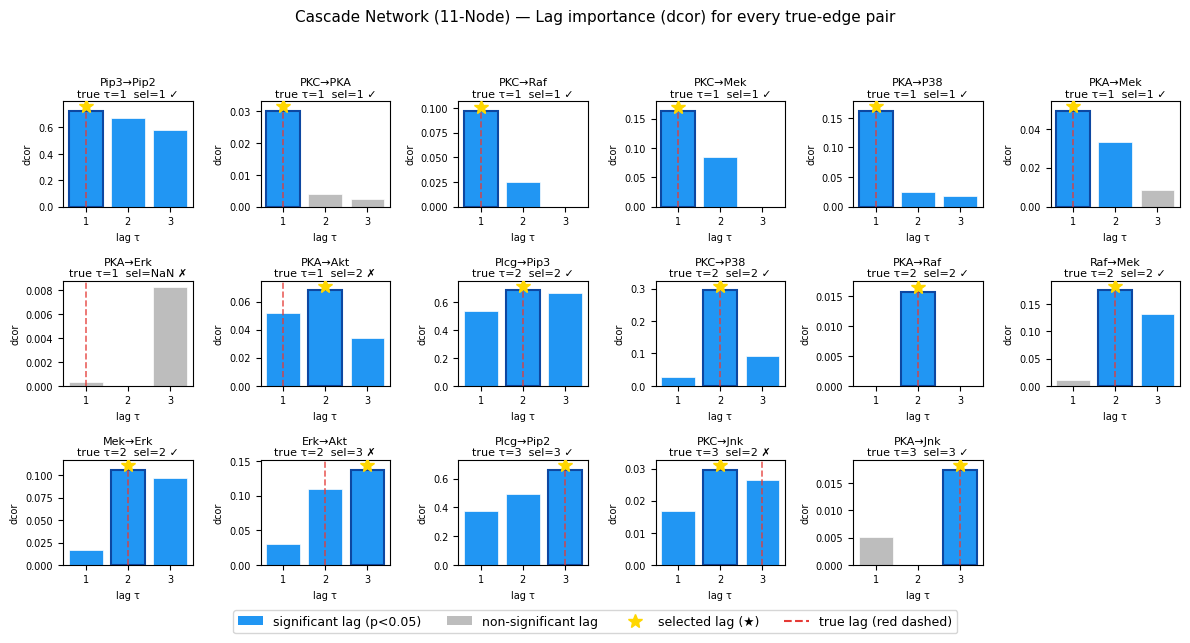

In [24]:
import causalts.plotting as tp
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

ds_name = 'ex3'
data = load_dataset(ds_name)
df, gt, ml = data['df'], data['gt_clean'], data['max_lag']
cols = list(df.columns)

from causalts.cedar.discovery import _normalize
from causalts.cedar.lag_selection import (
    compute_lag_importance, compute_lag_pvalues,
    select_lags, select_all_significant_lags,
)

data_norm = _normalize(df.values.astype(np.float64), 'minmax')
lag_imp   = compute_lag_importance(data_norm, ml, method='dcor')
lag_pvals = compute_lag_pvalues(data_norm, lag_imp, ml, method='t_test')
sel_lags  = select_lags(lag_imp, lag_pvals, alpha=0.05)
sig_mask  = select_all_significant_lags(lag_imp, lag_pvals, alpha=0.05)

# All true-edge pairs (ordered by true lag for readability)
true_edges = [(c, e, lag) for lag in range(gt.shape[2])
              for c, e in np.argwhere(gt[:, :, lag] == 1)]

lags_x  = list(range(1, ml + 1))
n_panels = len(true_edges)
ncols = 6
nrows = (n_panels + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2, nrows * 2), sharey=False)
all_axes = axes.flatten()  # use flatten() so we can index it twice

for ax, (c, e, true_lag) in zip(all_axes, true_edges):
    scores = [lag_imp[c, e, k] for k in lags_x]
    sigs   = [sig_mask[c, e, k] for k in lags_x]
    colors = ['#2196F3' if s else '#BDBDBD' for s in sigs]

    ax.bar(lags_x, scores, color=colors, edgecolor='white', linewidth=0.5)

    # Highlight selected lag with darker border + gold star
    sel = sel_lags[c, e]
    if not np.isnan(sel):
        k = int(sel)
        ax.bar([k], [lag_imp[c, e, k]], color='#2196F3', edgecolor='#0D47A1', linewidth=1.5)
        ax.plot(k, lag_imp[c, e, k] + max(scores) * 0.05, '*',
                color='gold', markersize=10, zorder=5)

    # True lag as dashed red vertical line
    ax.axvline(true_lag, color='#E53935', linestyle='--', linewidth=1.2, alpha=0.8)

    sel_str = str(int(sel)) if not np.isnan(sel) else 'NaN'
    tick = '✓' if (not np.isnan(sel) and int(sel) == true_lag) else '✗'
    ax.set_title(f"{cols[c]}→{cols[e]}\ntrue τ={true_lag}  sel={sel_str} {tick}",
                 fontsize=8, pad=3)
    ax.set_xlabel("lag τ", fontsize=7)
    ax.set_ylabel("dcor", fontsize=7)
    ax.set_xticks(lags_x)
    ax.tick_params(labelsize=7)
    ax.set_ylim(bottom=0)

# Hide unused subplot slots
for ax in all_axes[n_panels:]:
    ax.set_visible(False)

legend_elements = [
    Patch(facecolor='#2196F3', label='significant lag (p<0.05)'),
    Patch(facecolor='#BDBDBD', label='non-significant lag'),
    Line2D([0], [0], marker='*', color='gold', markersize=10,
           linestyle='none', label='selected lag (★)'),
    Line2D([0], [0], color='#E53935', linestyle='--',
           linewidth=1.5, label='true lag (red dashed)'),
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=4, fontsize=9, bbox_to_anchor=(0.5, -0.04))
fig.suptitle(
    f"{data['name']} — Lag importance (dcor) for every true-edge pair\n",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.show()

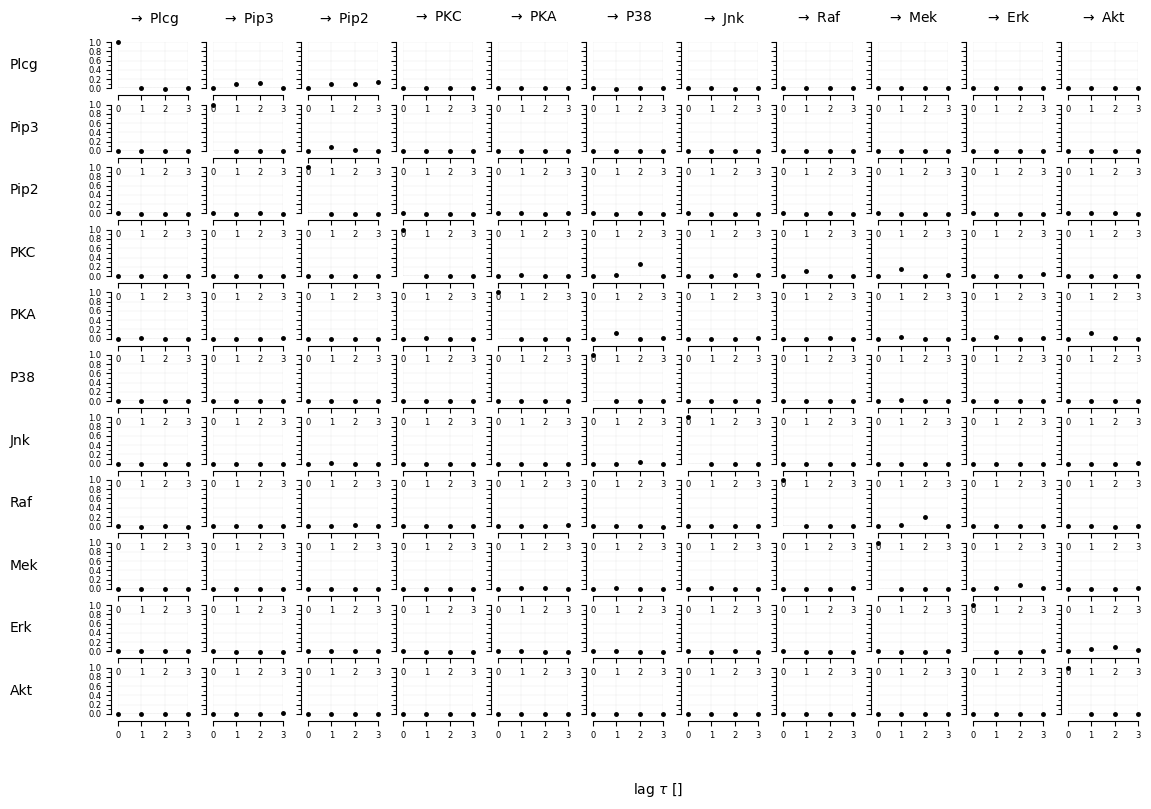

In [25]:
result.plot_lag_importance(figsize=(12, 8), maximum=1.0, show_gridlines=True);

## 4. Scaling to Larger Graphs (d=20)

Test CEDAR on a 20-variable Erdos-Renyi graph.

In [26]:
data_large = sd.erdos_renyi(n_vars=20, T=500, max_lag=2, seed=42)
df_l = data_large['df']
gt_l = data_large['ground_truth'].copy()
for lag in range(gt_l.shape[2]):
    np.fill_diagonal(gt_l[:, :, lag], 0)
ml_l = data_large['max_lag']
d_l = df_l.shape[1]
gt_edges = int(gt_l.astype(bool).sum())

print(f'Erdos-Renyi: d={d_l}, T={df_l.shape[0]}, max_lag={ml_l}, GT edges={gt_edges}')
print()

#nonlinear tests are more appropriate for this nonlinear data, but let's keep it simple for the demo
ci = ParCorrGPU(np.zeros((2,2)), device=DEVICE)
print(f"{'Method':30s} | {'Time':>7s} | {'E':>3s} | {'Prec':>5s} {'Rec':>5s} {'F1':>5s} {'SHD':>4s}")
print('-' * 70)

# CDNOTS
t0 = time.time()
cr = run_cdnots(df_l, ci, num_lags=ml_l, alpha=0.05)
t1 = time.time() - t0
p, r, f, s, e = eval_graph(cr.cg_tig[:d_l, :d_l, :], gt_l)
print(f'{"CDNOTS":30s} | {t1:6.2f}s | {e:3d} | {p:.3f} {r:.3f} {f:.3f} {s:>4}')

# CEDAR keep=first
t0 = time.time()
r1 = run_cedar(df_l, ci, max_lag=ml_l, multi_lag_keep='first')
t1 = time.time() - t0
p, r, f, s, e = eval_graph(r1.cg_tig, gt_l)
print(f'{"CEDAR keep=first":30s} | {t1:6.2f}s | {e:3d} | {p:.3f} {r:.3f} {f:.3f} {s:>4}')

# CEDAR keep=all
t0 = time.time()
r2 = run_cedar(df_l, ci, max_lag=ml_l, multi_lag_keep='all')
t1 = time.time() - t0
p, r, f, s, e = eval_graph(r2.cg_tig, gt_l)
print(f'{"CEDAR keep=all":30s} | {t1:6.2f}s | {e:3d} | {p:.3f} {r:.3f} {f:.3f} {s:>4}')

Erdos-Renyi: d=20, T=500, max_lag=2, GT edges=25

Method                         |    Time |   E |  Prec   Rec    F1  SHD
----------------------------------------------------------------------
CDNOTS                         |   0.18s |  35 | 0.686 0.960 0.800   12
CEDAR keep=first            |   0.21s |  29 | 0.793 0.920 0.852    8
CEDAR keep=all              |   0.19s |  32 | 0.719 0.920 0.807   11


## 5. Target-Variable Mode

**Unique to CEDAR:** Discover causes of a single target variable without running the full d-variable machinery. This is especially valuable for:
- Large systems where you only care about one outcome
- Root-cause analysis: "what drives variable X?"
- Interactive exploration: test one variable at a time

CDNOTS, GRACE, and PCMCI do NOT support this — they always discover the full graph.


Full graph discovery took 0.19s
Single-target discovery took 0.02s


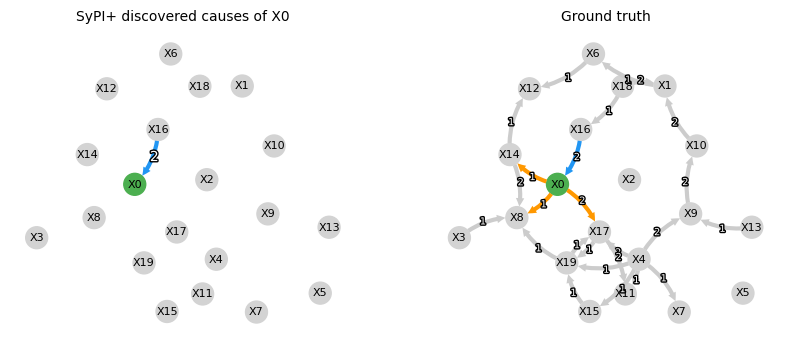

In [27]:
# Demo on the d=20 graph: discover causes of one variable
target = df_l.columns[0]  # pick a variable

# Full graph discovery
t0 = time.time()
full_result = run_cedar(df_l, ci, max_lag=ml_l)
t_full = time.time() - t0

# Single-target discovery
t0 = time.time()
target_result = run_cedar(df_l, ci, max_lag=ml_l, target_var=target)
t_target = time.time() - t0
print(f"\nFull graph discovery took {t_full:.2f}s")
print(f"Single-target discovery took {t_target:.2f}s")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
_,_,pos = tp.plot_graph(
    data_large['ground_truth'], var_names=data_large['var_names'], fig_ax=(fig, axes[1]),
    target_node=target, edge_color="#CCCCCC",    target_in_color="#2196F3",
    target_out_color="#FF9800",
    target_node_color="#4CAF50",
    node_size=.15, node_label_size=8, link_label_fontsize=7, return_pos=True
)

target_result.plot(node_size=.15, node_label_size=8, target_node=target,
    node_pos=pos, edge_color="#CCCCCC",
    target_in_color="#2196F3",
    target_out_color="#FF9800",
    target_node_color="#4CAF50",
    fig_ax=(fig, axes[0]));

axes[0].set_title(f"CEDAR discovered causes of {target}", fontsize=10)
axes[1].set_title(f"Ground truth", fontsize=10);

In [28]:
# Scaling comparison: target-only vs full across different d
print(f"{'d':>4s} | {'Full time':>10s} | {'Target time':>12s} | {'Speedup':>8s}")
print('-' * 50)

for n_vars in [10, 15, 20, 30]:
    data_s = sd.erdos_renyi(n_vars=n_vars, T=500, max_lag=2, seed=42)
    df_s = data_s['df']
    ci_s = ParCorrGPU(np.zeros((2,2)), device=DEVICE)
    target_s = df_s.columns[0]

    t0 = time.time()
    run_cedar(df_s, ci_s, max_lag=2)
    t_full_s = time.time() - t0

    t0 = time.time()
    run_cedar(df_s, ci_s, max_lag=2, target_var=target_s)
    t_target_s = time.time() - t0

    speedup = t_full_s / t_target_s if t_target_s > 0 else float('inf')
    print(f'{n_vars:>4d} | {t_full_s:>9.2f}s | {t_target_s:>11.2f}s | {speedup:>7.1f}x')

   d |  Full time |  Target time |  Speedup
--------------------------------------------------
  10 |      0.07s |        0.01s |     7.9x
  15 |      0.12s |        0.01s |     8.8x
  20 |      0.21s |        0.02s |    11.1x
  30 |      0.49s |        0.03s |    17.2x


## 6. Nonlinear Datasets

For nonlinear data, use SplitKCI or KCI instead of ParCorr.

In [29]:
data_nl = load_dataset('ex1_nl')
df_nl, gt_nl, ml_nl = data_nl['df'], data_nl['gt_clean'], data_nl['max_lag']
d_nl = df_nl.shape[1]
gt_nl_edges = int(gt_nl.astype(bool).sum())

print(f"ex1_nl ({data_nl['name']}) — GT: {gt_nl_edges} edges")
print(f"Contains squared (X0^2) terms that linear tests cannot detect.")
print()
print(f"{'Method':39s} | {'Time':>7s} | {'E':>3s} | {'Prec':>5s} {'Rec':>5s} {'F1':>5s} {'SHD':>4s}")
print('-' * 78)

for ci_name, ci_obj in [
    ('ParCorrGPU (linear)', ParCorrGPU(np.zeros((2,2)), device=DEVICE)),
    ('SplitKCIGPU (kernel)', SplitKCIGPU(np.zeros((2,2)), device=DEVICE)),
    ('KCIGPU (kernel, HBE)', KCIGPU(np.zeros((2,2)), device=DEVICE, approx='hbe')),
]:
    # CDNOTS
    t0 = time.time()
    cr = run_cdnots(df_nl, ci_obj, num_lags=ml_nl, alpha=0.05)
    t1 = time.time() - t0
    p, r, f, s, e = eval_graph(cr.cg_tig[:d_nl, :d_nl, :], gt_nl)
    print(f'CDNOTS + {ci_name:30s} | {t1:6.1f}s | {e:3d} | {p:.3f} {r:.3f} {f:.3f} {s:>4}')

    # CEDAR
    t0 = time.time()
    r2 = run_cedar(df_nl, ci_obj, max_lag=ml_nl)
    t1 = time.time() - t0
    p, r, f, s, e = eval_graph(r2.cg_tig, gt_nl)
    print(f'CEDAR  + {ci_name:30s} | {t1:6.1f}s | {e:3d} | {p:.3f} {r:.3f} {f:.3f} {s:>4}')
    print()

ex1_nl (5-Node Nonlinear System) — GT: 5 edges
Contains squared (X0^2) terms that linear tests cannot detect.

Method                                  |    Time |   E |  Prec   Rec    F1  SHD
------------------------------------------------------------------------------
CDNOTS + ParCorrGPU (linear)            |    0.0s |   3 | 0.667 0.400 0.500    4
CEDAR  + ParCorrGPU (linear)            |    0.0s |   2 | 1.000 0.400 0.571    3

CDNOTS + SplitKCIGPU (kernel)           |    5.4s |   3 | 1.000 0.600 0.750    2
CEDAR  + SplitKCIGPU (kernel)           |    0.2s |   4 | 1.000 0.800 0.889    1

CDNOTS + KCIGPU (kernel, HBE)           |   10.9s |   3 | 1.000 0.600 0.750    2
CEDAR  + KCIGPU (kernel, HBE)           |    0.4s |   4 | 0.750 0.600 0.667    3



## 7. Plotting

CEDAR results integrate with the standard plotting API.

CedarResult(vars=6, max_lag=3, edges=12, lag_method='partial_dcor', lag_pvalue_method='t_test', alpha_cond1=0.05, alpha_cond2=0.05, pruned=True, n_tests=40)


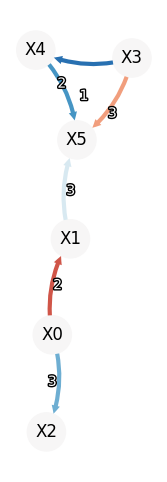

In [30]:
data_ex2 = load_dataset('ex2')
ci = ParCorrGPU(np.zeros((2,2)), device=DEVICE)
result = run_cedar(data_ex2['df'], ci, max_lag=3)
print(result)
result.plot(figsize=(8, 6));

## 8. Background Knowledge

`run_cedar` accepts `forbidden` and `required` edge lists.
Each entry is `(cause_var, effect_var, lag)` — pass `None` as lag to cover all lags.

- **Forbidden** edges are skipped before any CI test (zero wasted computation).
- **Required** edges are force-included in the final graph and protected from MCI pruning.

In [31]:
data_ex2 = load_dataset('ex2')
df_ex2   = data_ex2['df']
gt_ex2   = data_ex2['gt_clean']
cols_ex2 = list(df_ex2.columns)
ci_bk    = ParCorrGPU(np.zeros((2, 2)), device=DEVICE)

# Baseline — no background knowledge
res_base = run_cedar(df_ex2, ci_bk, max_lag=3)
p, r, f, s, e = eval_graph(res_base.cg_tig, gt_ex2)
print(f"Baseline : F1={f:.3f}  Prec={p:.3f}  Rec={r:.3f}  SHD={s}")

# Identify one FP (spurious) and one FN (missed) from the baseline
d_ex2 = df_ex2.shape[1]
fps = [
    (cols_ex2[c], cols_ex2[eff], int(tau))
    for c in range(d_ex2) for eff in range(d_ex2) for tau in range(1, 4)
    if res_base.cg_tig[c, eff, tau] == 1 and gt_ex2[c, eff, tau] == 0 and c != eff
]
fns = [
    (cols_ex2[c], cols_ex2[eff], int(tau))
    for c in range(d_ex2) for eff in range(d_ex2) for tau in range(1, 4)
    if res_base.cg_tig[c, eff, tau] == 0 and gt_ex2[c, eff, tau] == 1 and c != eff
]
print(f"FPs: {fps[:2]}  FNs: {fns[:2]}")

# Apply background knowledge: forbid the first FP, require the first FN
ci_bk2  = ParCorrGPU(np.zeros((2, 2)), device=DEVICE)
res_bk  = run_cedar(
    df_ex2, ci_bk2, max_lag=3,
    forbidden=fps[:1],   # remove a spurious edge
    required=fns[:1],    # restore a missed edge
)
p2, r2, f2, s2, e2 = eval_graph(res_bk.cg_tig, gt_ex2)
print(f"With BK  : F1={f2:.3f}  Prec={p2:.3f}  Rec={r2:.3f}  SHD={s2}")
print(res_bk)

Baseline : F1=0.615  Prec=0.667  Rec=0.571  SHD=5.0
FPs: [('X1', 'X5', 3), ('X3', 'X5', 3)]  FNs: [('X0', 'X3', 2), ('X2', 'X5', 1)]
With BK  : F1=0.833  Prec=1.000  Rec=0.714  SHD=2.0
CedarResult(vars=6, max_lag=3, edges=11, lag_method='partial_dcor', lag_pvalue_method='t_test', alpha_cond1=0.05, alpha_cond2=0.05, pruned=True, n_tests=37, forbidden=1, required=1)


## 9. Effect Estimation (DoWhy)

`CedarResult` inherits the full DoWhy bridge from `CausalResult`.
After discovery, call `.estimate_effect()` for ATE or `.fit_scm()` + `.counterfactual()`
for what-if analysis. Requires `pip install causalts[dowhy]`.

In [33]:
data_ex3 = load_dataset('ex3')
df_ex3   = data_ex3['df']
gt_ex3   = data_ex3['gt_clean']
cols_ex3 = list(df_ex3.columns)
ci_bk    = ParCorrGPU(np.zeros((2, 2)), device=DEVICE)

# Baseline — no background knowledge
res_base = run_cedar(df_ex3, ci_bk, max_lag=3)

try:
    # Reuse the background-knowledge result (ex3, 11 vars)
    # ATE: causal effect of PKC(t-1) on Mek(t)
    effect = res_base.estimate_effect(
        treatment='PKC', outcome='Mek', treatment_lag=1,
        method='backdoor.linear_regression',
        confidence_intervals=False,
    )
    print(f"ATE  PKC(t-1) → Mek : {effect.value:+.4f}")

    # SCM + counterfactual: what if PKC were zero?
    _, _, lagged_df = res_base.fit_scm(mechanism_type='linear')
    cf = res_base.counterfactual(intervention={'PKC_lag1': 0.0}, target='Mek')
    print(f"Counterfactual Mek (do PKC=0) : mean={cf.mean():+.4f}  "
          f"vs observed mean={lagged_df['Mek'].mean():+.4f}")

except ImportError:
    print("DoWhy not installed. Run:  pip install 'causalts[dowhy]'")

ATE  PKC(t-1) → Mek : -0.6822


Fitting causal mechanism of node Akt_lag3: 100%|██████████| 44/44 [00:00<00:00, 1590.81it/s]

Counterfactual Mek (do PKC=0) : mean=-0.0539  vs observed mean=-0.0315


## 10. Missing Values

CEDAR supports two missing-value strategies via the `impute` parameter:

| Strategy | `impute=` | When to use |
|---|---|---|
| **Pairwise-complete** (default) | `None` or `'pairwise_complete'` | MCAR data, moderate missingness (< 30%) |
| **VAR-EM** | `'var_em'` | MAR data, higher missingness or when pairwise gives noisy results |

`pairwise_complete` drops NaN rows independently for each CI test — zero pre-processing,
works transparently. `var_em` fits a VAR model iteratively and fills NaN before discovery,
producing a complete DataFrame that all three phases see consistently. It can inject spurious causal structure!

In [34]:
# Introduce 15% random NaN into the ex2 dataset
data_mv = load_dataset('ex2')
df_full = data_mv['df']
gt_mv   = data_mv['gt_clean']

rng = np.random.default_rng(42)
arr = df_full.to_numpy(dtype=float).copy()
mask_mv = rng.random(arr.shape) < 0.15
arr[mask_mv] = np.nan
df_miss = pd.DataFrame(arr, columns=df_full.columns)
print(f"Missing: {mask_mv.sum()} / {mask_mv.size}  ({100*mask_mv.mean():.1f}%)")

ci_full    = ParCorrGPU(np.zeros((2, 2)), device=DEVICE)
ci_pw      = ParCorrGPU(np.zeros((2, 2)), device=DEVICE)
ci_varem   = ParCorrGPU(np.zeros((2, 2)), device=DEVICE)

# Strategy 1: pairwise-complete (default) — NaN rows dropped per CI test
res_full    = run_cedar(df_full, ci_full,  max_lag=3)
res_pw      = run_cedar(df_miss, ci_pw,    max_lag=3)

# Strategy 2: VAR-EM — fill NaN before discovery (better for MCAR/MAR data)
res_varem   = run_cedar(df_miss, ci_varem, max_lag=3, impute='var_em')

pf, rf, ff, sf, _ = eval_graph(res_full.cg_tig,  gt_mv)
pp, rp, fp, sp, _ = eval_graph(res_pw.cg_tig,    gt_mv)
pv, rv, fv, sv, _ = eval_graph(res_varem.cg_tig, gt_mv)

print(f"No missing          :  F1={ff:.3f}  Prec={pf:.3f}  Rec={rf:.3f}  SHD={sf}  n_tests={res_full.n_tests}")
print(f"15% NaN, pairwise   :  F1={fp:.3f}  Prec={pp:.3f}  Rec={rp:.3f}  SHD={sp}  n_tests={res_pw.n_tests}")
print(f"15% NaN, var_em     :  F1={fv:.3f}  Prec={pv:.3f}  Rec={rv:.3f}  SHD={sv}  n_tests={res_varem.n_tests}")

Missing: 272 / 1800  (15.1%)
No missing          :  F1=0.615  Prec=0.667  Rec=0.571  SHD=5.0  n_tests=40
15% NaN, pairwise   :  F1=0.833  Prec=1.000  Rec=0.714  SHD=2.0  n_tests=43
15% NaN, var_em     :  F1=0.571  Prec=0.571  Rec=0.571  SHD=6.0  n_tests=45


## 11. Nonstationary Time Series (C Node)

When variables share a common time trend (nonstationarity), spurious correlations appear between them. CEDAR handles this the same way as CDNOTS: set `include_C=True` to append a time-index basis **C** and treat it as a pure cause.

**Dataset:** `confounded_trends` — 7 variables where 5 (Chocolate, IceCream, Sunburn, Airline, Fuel) share a quadratic population-growth trend. The ONLY real causal link is Temp(t-2) → Energy.

| Variable | Driven by |
|----------|-----------|
| Chocolate, IceCream, Airline | Shared quadratic trend only |
| Sunburn, Fuel | Shared trend + autoregression |
| Temp | Autoregression only (no trend) |
| Energy | `Temp(t-2)` — the only real cause |

**CEDAR vs CDNOTS on nonstationarity:** CEDAR's CI test structure (conditioning on Y(t-1) + other candidates) already filters cross-variable trend-confounded edges without needing C. The benefit of `include_C` in CEDAR is **causal attribution**: `C→X` edges explicitly identify which variables are driven by the shared trend, rather than leaving the trend as an implicit confounder.

Setting `c_preset='linear+quad'` appends C_lin and C_quad columns. CEDAR then discovers edges from both C columns to each trend-driven variable.

> **Note:** `include_autoreg=False` is used below to focus on cross-variable edges. The default `include_autoreg=True` unconditionally adds AR(1) self-loops for all variables (including purely trend-driven ones like Chocolate that have no genuine AR structure), which obscures the C-node attribution story.

**CLI equivalent:**
```bash
causal-ts discover data.csv -a cedar --include-c --c-preset linear+quad --max-lag 2 --no-autoreg
```


In [35]:
from causalts.synthetic_data.synthetic_datasets import confounded_trends

data_ct = confounded_trends(seed=42)
df_ct   = data_ct['df']
gt_ct   = data_ct['ground_truth'].copy()
for lag in range(gt_ct.shape[2]):
    np.fill_diagonal(gt_ct[:, :, lag], 0)  # remove self-lags from evaluation
d_ct = df_ct.shape[1]
cols_ct = list(df_ct.columns)
cols_ct_c = cols_ct + ['C_lin', 'C_quad']

print(f"Dataset: {data_ct['name']}")
print(f"Variables: {cols_ct}")
print(f"True causal edges (non-self): {int(gt_ct.astype(bool).sum())}  [only Temp(t-2)->Energy]")
print()

ci_no = ParCorrGPU(np.zeros((2, 2)), device=DEVICE)
ci_c  = ParCorrGPU(np.zeros((2, 2)), device=DEVICE)

# Without C: default include_autoreg=True adds AR(1) self-loops unconditionally.
# Many are spurious -- trend-driven variables (Chocolate, IceCream, Airline)
# look AR(1) because the trend makes X(t) and X(t-1) nearly identical.
res_no = run_cedar(df_ct, ci_no, max_lag=2, include_C=False)

# With C: C columns capture the shared trend, so unconditional AR self-loops
# are no longer needed. include_autoreg=False gives a clean graph where only
# the true edge remains, while C->X edges identify the trend-driven variables.
res_c  = run_cedar(df_ct, ci_c,  max_lag=2, include_C=True, c_preset='linear+quad',
                  include_autoreg=False)

# Evaluate only the 7x7 subgraph (variables, excluding C rows)
p_no, r_no = precision_recall_3d(gt_ct, res_no.cg_tig)
f_no = 2 * p_no * r_no / (p_no + r_no) if (p_no + r_no) > 0 else 0
res_c_7x7 = res_c.cg_tig[:d_ct, :d_ct, :]
p_c, r_c = precision_recall_3d(gt_ct, res_c_7x7)
f_c = 2 * p_c * r_c / (p_c + r_c) if (p_c + r_c) > 0 else 0

print(f"{'Method':<30} {'F1':>6} {'Prec':>6} {'Rec':>6} {'Edges':>6}")
print('-' * 55)
print(f"{'No C':<30} {f_no:>6.3f} {p_no:>6.3f} {r_no:>6.3f} {int(res_no.cg_tig.astype(bool).sum()):>6}")
print(f"{'include_C (linear+quad)':<30} {f_c:>6.3f} {p_c:>6.3f} {r_c:>6.3f} {int(res_c_7x7.astype(bool).sum()):>6}  (+{int(res_c.cg_tig.astype(bool).sum() - res_c_7x7.astype(bool).sum())} C edges)")
print()
print("Spurious edges without C:")
for c in range(d_ct):
    for e in range(d_ct):
        for lag in range(3):
            if res_no.cg_tig[c, e, lag] and not gt_ct[c, e, lag]:
                print(f"  FP: {cols_ct[c]}(t-{lag}) -> {cols_ct[e]}")

print()
print("C edges detected (with C) -- variables attributed to the shared trend:")
for c_i in range(d_ct, d_ct + 2):
    for e_j in range(d_ct):
        if res_c.cg_tig[c_i, e_j, :].any():
            lag = int(np.argmax(res_c.cg_tig[c_i, e_j, :]))
            print(f"  {cols_ct_c[c_i]}(t-{lag}) -> {cols_ct[e_j]}")


Dataset: Confounded Trends (7-Node)
Variables: ['Chocolate', 'IceCream', 'Sunburn', 'Airline', 'Fuel', 'Temp', 'Energy']
True causal edges (non-self): 1  [only Temp(t-2)->Energy]

Method                             F1   Prec    Rec  Edges
-------------------------------------------------------
No C                            0.222  0.125  1.000      8
include_C (linear+quad)         1.000  1.000  1.000      1  (+10 C edges)

Spurious edges without C:
  FP: Chocolate(t-1) -> Chocolate
  FP: IceCream(t-1) -> IceCream
  FP: Sunburn(t-1) -> Sunburn
  FP: Airline(t-1) -> Airline
  FP: Fuel(t-1) -> Fuel
  FP: Temp(t-1) -> Temp
  FP: Energy(t-1) -> Energy

C edges detected (with C) -- variables attributed to the shared trend:
  C_lin(t-0) -> Chocolate
  C_lin(t-0) -> IceCream
  C_lin(t-0) -> Sunburn
  C_lin(t-0) -> Airline
  C_lin(t-0) -> Fuel
  C_quad(t-0) -> Chocolate
  C_quad(t-0) -> IceCream
  C_quad(t-0) -> Sunburn
  C_quad(t-0) -> Airline
  C_quad(t-0) -> Fuel
